In [59]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.loader import load_specs
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level, load_trading_model_3level
from tradepy.supervised.backtest import prepare_bt, create_test_dataset, predict_in_batches, run_backtest_complete, run_backtest_complete_scalein, run_backtest_sizing_only, run_backtest_scalein_sizing, build_overlapping_blocks, monte_carlo_blocks, backtest_grid_search, plot_equities, max_drawdown, max_losing_streak, plot_conjunto, load_bt_csv
from tradepy.paths import MODELS_DIR, BT_DIR

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt


In [60]:
start = "2026-03-27"
# start = "2026-01-20"
end   = "2026-06-01"

In [61]:
symbols = load_symbols()
cfg = load_config()

In [62]:
ASSET = symbols[12]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [63]:
best = pd.read_json(f"{MODELS_DIR}/best_per_asset.json")

In [64]:
best

,CL,ES,GC,MFXI,NG,NQ,YM,ZB,ZN,ZS
strat,df_long,df_long,df_long,df_ops_strong,df_long_strong,df_long,df_ops_strong,df_ops_strong,df_ops,df_ops_strong
backtest,scalein_sizing,sizing,sizing,sizing,sizing,sizing,scalein_sizing,sizing,sizing,scalein
calmar,8.2257,-0.1219,1.0427,0.3551,0.188,-0.1673,0.2288,1.2188,0.8609,6.2328
sharpe,1.6833,-0.374,0.8643,0.4044,0.1657,-0.5267,0.3576,0.6243,0.8552,1.4829
max_dd,0.0312,0.1515,0.0327,0.0389,0.006,0.1096,0.0549,0.0123,0.0488,0.4148
cagr,0.2569,-0.0185,0.034,0.0138,0.0011,-0.0183,0.0126,0.015,0.042,2.5851
equity_final,506350.0,335276.9546,485851.982,5091.4967,70180.8087,622842.5448,205835.0,51741.2361,32986.8392,501375.0
pnl_final,206350.0,-14723.0454,35851.982,91.4967,180.8087,-27157.4552,5835.0,1741.2361,2986.8392,451375.0
equity_path,E:\Futuro\MLAlgoTrading\TradingBots\Models/cl/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/es/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/mfx...,E:\Futuro\MLAlgoTrading\TradingBots\Models/ng/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/nq/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/ym/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zb/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zn/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zs/...
trades_path,E:\Futuro\MLAlgoTrading\TradingBots\Models/cl/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/es/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/mfx...,E:\Futuro\MLAlgoTrading\TradingBots\Models/ng/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/nq/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/ym/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zb/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zn/...,E:\Futuro\MLAlgoTrading\TradingBots\Models/zs/...


In [65]:
best.columns

Index(['CL', 'ES', 'GC', 'MFXI', 'NG', 'NQ', 'YM', 'ZB', 'ZN', 'ZS'], dtype='str')

In [66]:
# dfs = {}
# for asset in best.columns:
#     df_bt, _ = prepare_bt(asset, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")
#     mask = (df_bt["datetime"] >= start) & (df_bt["datetime"] < end)
#     df_filtered = df_bt.loc[mask]
#     df_filtered["hour"] = df_filtered["datetime"].dt.hour
#     dfs[asset] = df_filtered
#     trades = pd.read_parquet(f"{MODELS_DIR}/{asset}/trades_best.parquet")
#     # equity = pd.read_parquet(f"{MODELS_DIR}/{asset}/equity_best.parquet")
#     dfs[asset]["equity"] = equity.values


In [67]:
dfs = {}
for asset in best.columns:
    trades = pd.read_parquet(f"{MODELS_DIR}/{asset}/trades_best.parquet")
    dfs[asset] = trades

In [68]:
specs = load_specs()

In [69]:
df_minutes = pd.date_range(start=start, end=end, freq=f"{MINUTES} min", tz="UTC").to_frame(index=False, name="datetime")

In [70]:
df_minutes

,datetime
0,2026-03-27 00:00:00+00:00
1,2026-03-27 04:00:00+00:00
2,2026-03-27 08:00:00+00:00
3,2026-03-27 12:00:00+00:00
4,2026-03-27 16:00:00+00:00
...,...
392,2026-05-31 08:00:00+00:00
393,2026-05-31 12:00:00+00:00
394,2026-05-31 16:00:00+00:00
395,2026-05-31 20:00:00+00:00


In [71]:
dfs[ASSET]

,type,entry,exit,pnl_points,pnl_usd,datetime_exit,date
0,long,1092.265,1099.4375,7.1725,35862.5,2026-01-28 08:00:00+00:00,2026-01-28
1,long,1098.265,1104.8325,6.5675,32837.5,2026-01-28 16:00:00+00:00,2026-01-28
2,long,1098.765,1105.4550,6.6900,33450.0,2026-01-28 16:00:00+00:00,2026-01-28
3,long,1101.765,1109.3625,7.5975,37987.5,2026-01-29 16:00:00+00:00,2026-01-29
4,long,1100.765,1108.6000,7.8350,39175.0,2026-01-29 16:00:00+00:00,2026-01-29
5,long,1101.015,1108.6050,7.5900,37950.0,2026-01-29 16:00:00+00:00,2026-01-29
6,long,1094.265,1088.3550,-5.9100,-29550.0,2026-01-30 20:00:00+00:00,2026-01-30
7,short,1089.485,1080.1050,9.3800,46900.0,2026-02-02 08:00:00+00:00,2026-02-02
8,long,1087.265,1094.8800,7.6150,38075.0,2026-02-03 16:00:00+00:00,2026-02-03
9,long,1088.015,1095.4150,7.4000,37000.0,2026-02-03 16:00:00+00:00,2026-02-03


In [72]:
rows = []
for asset, trades in dfs.items():
    t = trades.copy()
    t["asset"] = asset
    t["datetime_exit"] = pd.to_datetime(t["datetime_exit"], utc=True)
    t["initial_margin"] = specs[asset]["initial_margin"]
    fee_roundtrip = 2 * specs[asset]["approx_total_fee_per_side"]
    spread_roundtrip = 2 * specs[asset]["max_spread_ticks"] * specs[asset]["tick_value"]
    slippage_roundtrip = 2 * specs[asset]["min_slippage_ticks"] * specs[asset]["tick_value"]
    total_cost_roundtrip = fee_roundtrip + spread_roundtrip + slippage_roundtrip
    t["fee_roundtrip"] = total_cost_roundtrip
    # t["fee_roundtrip"] = 2 * specs[asset]["approx_total_fee_per_side"]

    rows.append(t)

all_trades = pd.concat(rows, ignore_index=True)
all_trades = all_trades.sort_values("datetime_exit").reset_index(drop=True)


In [73]:
# λ controla la duración media
lam = 1.0  

# número de bloques de 4h
all_trades["duration_blocks"] = np.random.poisson(lam, size=len(all_trades))

# evitar duración 0 → mínimo 1 bloque
all_trades["duration_blocks"] = all_trades["duration_blocks"].clip(lower=1)

# calcular datetime_entry
all_trades["datetime_entry"] = all_trades["datetime_exit"] - \
                              pd.to_timedelta(all_trades["duration_blocks"] * 4, unit="h")


In [74]:
# all_trades["datetime_entry"] = all_trades["datetime_exit"] - pd.Timedelta(hours=4)

In [75]:
mask = (all_trades["datetime_entry"] >= start) & (all_trades["datetime_entry"] <= end)
filtered = all_trades.loc[mask]

In [76]:
filtered

,type,entry,exit,pnl_points,pnl_usd,size,datetime_exit,date,asset,initial_margin,fee_roundtrip,duration_blocks,datetime_entry
223,short,46733.0000,46149.000000,584.000000,2920.000000,1.0,2026-03-27 12:00:00+00:00,2026-03-27,YM,20000,35.0,2,2026-03-27 04:00:00+00:00
224,short,46734.0000,46091.000000,643.000000,3215.000000,1.0,2026-03-27 12:00:00+00:00,2026-03-27,YM,20000,35.0,1,2026-03-27 08:00:00+00:00
225,long,46512.0000,46028.000000,-484.000000,-2420.000000,1.0,2026-03-27 12:00:00+00:00,2026-03-27,YM,20000,35.0,3,2026-03-27 00:00:00+00:00
226,long,6522.7500,6469.053882,-53.696118,-2684.805917,1.0,2026-03-27 16:00:00+00:00,2026-03-27,ES,35000,80.0,1,2026-03-27 12:00:00+00:00
227,long,46360.0000,46018.000000,-342.000000,-1710.000000,1.0,2026-03-27 16:00:00+00:00,2026-03-27,YM,20000,35.0,1,2026-03-27 12:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,long,7519.0000,7572.958089,53.958089,2697.904440,1.0,2026-05-28 16:00:00+00:00,2026-05-28,ES,35000,80.0,1,2026-05-28 12:00:00+00:00
412,short,1.1664,1.168410,-0.002010,-25.127308,1.0,2026-05-28 16:00:00+00:00,2026-05-28,MFXI,500,11.7,1,2026-05-28 12:00:00+00:00
413,long,109.6875,110.039075,0.351575,351.574619,1.0,2026-05-28 20:00:00+00:00,2026-05-28,ZN,3000,130.0,1,2026-05-28 16:00:00+00:00
414,short,1.1699,1.171858,-0.001958,-24.470280,1.0,2026-05-29 16:00:00+00:00,2026-05-29,MFXI,500,11.7,1,2026-05-29 12:00:00+00:00


In [77]:
import pandas as pd
import numpy as np

def backtest_multi_asset(df_trades, df_times, 
                         initial_capital=1_000_000,
                         risk_pct=1.0):
    """
    Simula un backtest multi-activo controlando paso a paso el capital total (equity)
    y el capital retenido en concepto de márgenes de garantía.
    
    df_trades: DataFrame con columnas obligatorias:
        type, entry, exit, pnl_points, pnl_usd, size, datetime_exit,
        datetime_entry, asset, initial_margin, fee_roundtrip
    df_times: DataFrame con la columna ordenada 'datetime'
    """

    # 1. Limpieza inicial y preparación de datos
    df_trades = df_trades.copy()
    
    # Rellenar tamaños nulos (como el de la fila de ZS) con una unidad por defecto
    df_trades["size"] = df_trades["size"].fillna(1.0)
    
    # Asegurar el tipado correcto de fechas
    df_trades["datetime_entry"] = pd.to_datetime(df_trades["datetime_entry"])
    df_trades["datetime_exit"] = pd.to_datetime(df_trades["datetime_exit"])
    df_times["datetime"] = pd.to_datetime(df_times["datetime"])

    # Ordenar cronológicamente para el bucle de simulación
    df_times = df_times.sort_values("datetime").reset_index(drop=True)

    # Inicializar las variables de estado de la cuenta
    equity = initial_capital
    available_capital = initial_capital
    margin_used = 0

    open_positions = []
    equity_curve = []

    # 2. Bucle principal de simulación temporal (Barra a Barra)
    for t in df_times["datetime"]:

        # A) GESTIÓN DE SALIDAS (Liberar Capital)
        # Identificar qué posiciones abiertas han alcanzado su momento de cierre en el instante 't'
        to_close = [pos for pos in open_positions if pos["datetime_exit"] == t]

        for pos in to_close:
            # PnL Neto = Ganancia/Pérdida en dólares - Comisiones de ida y vuelta
            # net_pnl = pos["pnl_usd"] - pos["fee_roundtrip"]
            net_pnl = pos["pnl_usd"]
            
            # Se consolida el resultado en el saldo neto de la cuenta
            equity += net_pnl
            
            # Se libera el margen de garantía que estaba retenido por la posición
            margin_used -= pos["initial_margin"] * pos["size"]
            
            # Se elimina de la lista de posiciones activas
            open_positions.remove(pos)

        # Actualizar el capital disponible tras los cierres
        available_capital = equity - margin_used

        # B) GESTIÓN DE ENTRADAS (Retener Capital)
        # Seleccionar todas las operaciones que pretenden abrirse exactamente en el instante 't'
        trades_now = df_trades[df_trades["datetime_entry"] == t]

        for _, tr in trades_now.iterrows():
            required_margin = tr["initial_margin"] * tr["size"]

            # Límite estricto de gestión de riesgo empresarial (Risk Management)
            max_capital_to_use = equity * risk_pct

            # Verificar si añadir este trade no excede el capital máximo permitido por riesgo
            # Y además que quede dinero real (capital disponible) en la cuenta para cubrir las garantías
            if (margin_used + required_margin <= max_capital_to_use) and (required_margin <= available_capital):
                # Se acepta la operación y se añade a la cartera activa
                open_positions.append(tr.to_dict())
                margin_used += required_margin
                available_capital = equity - margin_used

        # C) REGISTRO DEL ESTADO DE LA CUENTA
        equity_curve.append({
            "datetime": t,
            "equity": equity,
            "available_capital": available_capital,
            "margin_used": margin_used,
            "open_positions": len(open_positions)
        })

    return pd.DataFrame(equity_curve)

In [78]:
risk = 0.2
final_equity_risk = backtest_multi_asset(all_trades, df_minutes, risk_pct=risk)

<Axes: >

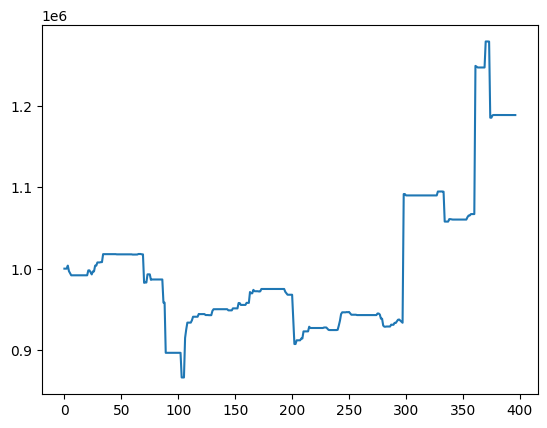

In [79]:
final_equity_risk["equity"].plot()

In [80]:
risk = 0.2
initial = 10000
final_equity_risk_menos = backtest_multi_asset(all_trades, df_minutes, risk_pct=risk, initial_capital=initial)

<Axes: >

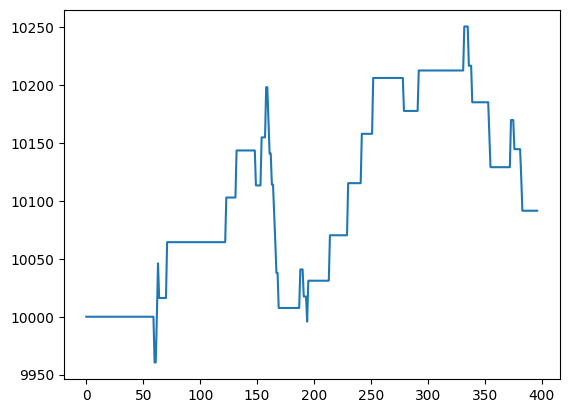

In [81]:
final_equity_risk_menos["equity"].plot()

In [82]:
def compute_metrics(equity_curve, periods_per_year=252*4):
    """
    equity_curve: DataFrame con columnas:
        datetime, equity
    periods_per_year: frecuencia anualizada (4h → 252*6 = 1512, 
                      pero si usas 4 timestamps por día → 252*4 = 1008)
    """

    eq = equity_curve["equity"].values
    returns = np.diff(eq) / eq[:-1]

    # -----------------------------
    # 1) Max Drawdown
    # -----------------------------
    running_max = np.maximum.accumulate(eq)
    dd = (eq - running_max) / running_max
    max_dd = dd.min()

    # -----------------------------
    # 2) Sharpe Ratio
    # -----------------------------
    sharpe = np.sqrt(periods_per_year) * returns.mean() / returns.std(ddof=1)

    # -----------------------------
    # 3) Sortino Ratio
    # -----------------------------
    downside = returns[returns < 0]
    if len(downside) > 0:
        sortino = np.sqrt(periods_per_year) * returns.mean() / downside.std(ddof=1)
    else:
        sortino = np.nan

    # -----------------------------
    # 4) CAGR (para MAR y Calmar)
    # -----------------------------
    total_return = eq[-1] / eq[0] - 1
    n_years = (equity_curve["datetime"].iloc[-1] - equity_curve["datetime"].iloc[0]).days / 365
    cagr = (eq[-1] / eq[0])**(1 / n_years) - 1 if n_years > 0 else np.nan

    # -----------------------------
    # 5) MAR Ratio
    # -----------------------------
    mar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    # -----------------------------
    # 6) Calmar Ratio
    # -----------------------------
    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "CAGR": cagr,
        "Max Drawdown": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "MAR": mar,
        "Calmar": calmar
    }


In [83]:
compute_metrics(final_equity_risk)

{'CAGR': np.float64(1.5989538063289848),
 'Max Drawdown': np.float64(-0.14887364177784562),
 'Sharpe': np.float64(1.189581305883457),
 'Sortino': np.float64(1.1493790327967432),
 'MAR': np.float64(10.740341857929415),
 'Calmar': np.float64(10.740341857929415)}

In [84]:
def plot_equity_and_trades(equity_curve, df_trades):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

    # -------------------------
    # PANEL 1: EQUITY CURVE
    # -------------------------
    ax1.plot(equity_curve["datetime"], equity_curve["equity"], 
             color="blue", linewidth=2)
    ax1.set_title("Equity Curve")
    ax1.grid(True, alpha=0.3)

    # -------------------------
    # PANEL 2: TRADES
    # -------------------------
    ax2.set_title("Trades (Long / Short)")
    ax2.grid(True, alpha=0.3)

    # Línea base
    ax2.plot(equity_curve["datetime"], 
             np.zeros(len(equity_curve)), 
             color="gray", alpha=0.3)

    # Entradas
    long_entries = df_trades[df_trades["type"] == "long"]
    short_entries = df_trades[df_trades["type"] == "short"]

    ax2.scatter(long_entries["datetime_entry"], 
    # ax2.scatter(long_entries["datetime_exit"], 
                np.zeros(len(long_entries)) + 0.5,
                marker="^", color="green", s=80, label="Long Entry")

    ax2.scatter(short_entries["datetime_entry"], 
    # ax2.scatter(short_entries["datetime_exit"], 
                np.zeros(len(short_entries)) - 0.5,
                marker="v", color="red", s=80, label="Short Entry")

    # Salidas
    ax2.scatter(df_trades["datetime_exit"], 
                np.zeros(len(df_trades)),
                marker="o", color="black", s=30, label="Exit")

    ax2.legend()
    plt.tight_layout()
    plt.show()


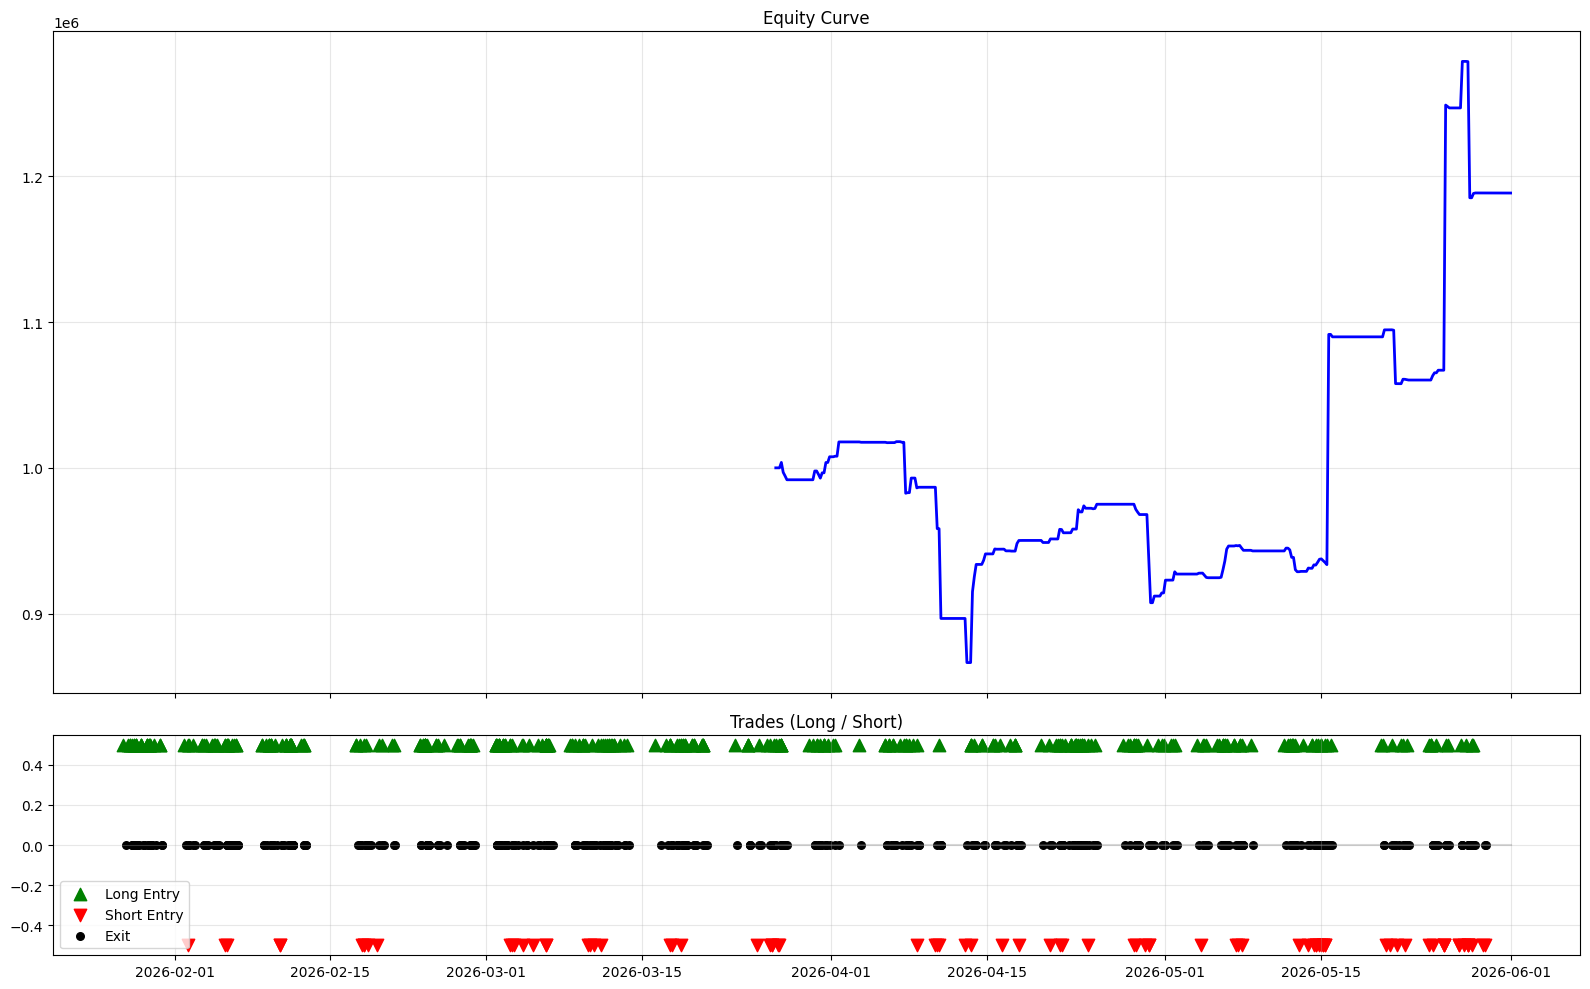

In [85]:
plot_equity_and_trades(final_equity_risk, all_trades)

In [86]:
"""
portfolio_backtest.py
---------------------
Backtest de cartera combinada a partir de trades individuales ya confirmados.

Lógica principal:
  - Recorre el timeline barra a barra (4h).
  - En cada barra cierra los trades que terminan y abre los que empiezan
    SOLO si hay capital suficiente (respetando max_exposure_pct).
  - El P&L no realizado se estima linealmente entre entry y exit
    (no hay datos intra-trade, es la mejor aproximación posible).
  - Se compara el resultado con un backtest "sin restricciones" de capital
    para ver cuánto se pierde por colisión de margin calls.

Uso básico:
    from portfolio_backtest import run_backtest, compare_vs_unlimited, print_metrics

    equity_df, summary = run_backtest(
        trades_df       = trades,
        timeline_df     = timeline,
        initial_capital = 1_000_000,
        max_exposure_pct = 0.50,   # máximo 50 % del equity en margin
    )
    print_metrics(summary)
    compare_vs_unlimited(trades_df=trades, timeline_df=timeline, initial_capital=1_000_000)
"""

import pandas as pd
import numpy as np
from typing import Optional


# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def _to_utc(series: pd.Series) -> pd.Series:
    """Convierte una columna de timestamps a UTC aware."""
    s = pd.to_datetime(series)
    if s.dt.tz is None:
        s = s.dt.tz_localize("UTC")
    else:
        s = s.dt.tz_convert("UTC")
    return s


def _unrealized_pnl(open_trades: list, t: pd.Timestamp) -> float:
    """
    Estima el P&L no realizado de los trades abiertos en el instante t,
    interpolando linealmente entre entry (pnl=0) y exit (pnl=pnl_usd - fee).
    """
    total = 0.0
    for tr in open_trades:
        duration = (tr["datetime_exit"] - tr["datetime_entry"]).total_seconds()
        if duration <= 0:
            progress = 1.0
        else:
            progress = (t - tr["datetime_entry"]).total_seconds() / duration
            progress = min(max(progress, 0.0), 1.0)
        net_pnl = tr["pnl_usd"] - tr["fee_roundtrip"]
        total += net_pnl * progress
    return total


def _max_drawdown(equity_series: pd.Series) -> float:
    """Máximo drawdown absoluto (en USD) de la curva de equity."""
    roll_max = equity_series.cummax()
    dd = equity_series - roll_max
    return float(dd.min())


def _max_drawdown_pct(equity_series: pd.Series) -> float:
    """Máximo drawdown porcentual."""
    roll_max = equity_series.cummax()
    dd_pct = (equity_series - roll_max) / roll_max
    return float(dd_pct.min())


def _sharpe(equity_series: pd.Series, bars_per_year: int = 6 * 252) -> float:
    """
    Sharpe ratio anualizado a partir de la curva de equity (barras de 4h).
    bars_per_year ≈ 6 barras/día × 252 días = 1512.
    """
    returns = equity_series.pct_change().dropna()
    if returns.std() == 0:
        return np.nan
    return float((returns.mean() / returns.std()) * np.sqrt(bars_per_year))


# ─────────────────────────────────────────────────────────────────────────────
# Backtest principal
# ─────────────────────────────────────────────────────────────────────────────

def run_backtest(
    trades_df: pd.DataFrame,
    timeline_df: pd.DataFrame,
    initial_capital: float = 1_000_000.0,
    max_exposure_pct: float = 0.50,
    priority: str = "fifo",          # 'fifo' | 'margin_asc' | 'margin_desc'
    verbose: bool = False,
) -> tuple[pd.DataFrame, dict]:
    """
    Backtest de cartera combinada con restricción de capital.

    Parameters
    ----------
    trades_df : DataFrame
        Trades individuales confirmados. Columnas requeridas:
        datetime_entry, datetime_exit, pnl_usd, initial_margin,
        fee_roundtrip, asset, type.
    timeline_df : DataFrame
        Columna 'datetime' con cada barra temporal del periodo.
    initial_capital : float
        Capital inicial en USD.
    max_exposure_pct : float
        Porcentaje máximo del equity que puede estar en margin (0–1).
        Ejemplo: 0.5 → no se puede tener más del 50 % del equity en margin.
    priority : str
        Orden de prioridad cuando varios trades compiten por capital en la
        misma barra:
          'fifo'        → orden original del DataFrame (sin cambios)
          'margin_asc'  → primero los de menor margen (más trades posibles)
          'margin_desc' → primero los de mayor margen
    verbose : bool
        Imprime por pantalla los trades saltados.

    Returns
    -------
    equity_df : DataFrame
        Curva de equity barra a barra con columnas:
        datetime, equity, cash, locked_margin, unrealized_pnl,
        n_open_trades.
    summary : dict
        Diccionario con métricas y listas de trades aceptados/rechazados.
    """

    # ── Preparar datos ────────────────────────────────────────────────────────
    trades = trades_df.copy().reset_index(drop=True)
    trades["datetime_entry"] = _to_utc(trades["datetime_entry"])
    trades["datetime_exit"] = _to_utc(trades["datetime_exit"])

    timeline = _to_utc(timeline_df["datetime"]).sort_values().reset_index(drop=True)

    # ── Estado ────────────────────────────────────────────────────────────────
    # cash = capital líquido (initial - margins_open + margins_returned + pnl_realizados)
    cash = float(initial_capital)
    open_trades: list[dict] = []
    accepted_trades: list[dict] = []
    skipped_trades: list[dict] = []

    # Índice: datetime_entry → lista de trades que entran en esa barra
    entry_index: dict[pd.Timestamp, list[dict]] = {}
    for _, row in trades.iterrows():
        key = row["datetime_entry"]
        entry_index.setdefault(key, []).append(row.to_dict())

    # Si priority != fifo, reordenar dentro de cada grupo
    if priority == "margin_asc":
        entry_index = {
            k: sorted(v, key=lambda x: x["initial_margin"])
            for k, v in entry_index.items()
        }
    elif priority == "margin_desc":
        entry_index = {
            k: sorted(v, key=lambda x: x["initial_margin"], reverse=True)
            for k, v in entry_index.items()
        }

    equity_records: list[dict] = []

    # ── Loop barra a barra ────────────────────────────────────────────────────
    for t in timeline:

        # 1. Cerrar trades que terminan en o antes de esta barra
        still_open = []
        for tr in open_trades:
            if tr["datetime_exit"] <= t:
                net_pnl = tr["pnl_usd"] - tr["fee_roundtrip"]
                cash += tr["initial_margin"] + net_pnl   # devolver margin + pnl
                tr["status"] = "closed"
                accepted_trades.append(tr)
            else:
                still_open.append(tr)
        open_trades = still_open

        # 2. Calcular equity ANTES de abrir nuevos
        locked_margin = sum(tr["initial_margin"] for tr in open_trades)
        unreal = _unrealized_pnl(open_trades, t)
        equity = cash + locked_margin + unreal

        # 3. Abrir trades que entran en esta barra
        if t in entry_index:
            for tr in entry_index[t]:
                new_margin = float(tr["initial_margin"])
                # Recalcular locked_margin con los ya abiertos hasta ahora
                locked_margin = sum(x["initial_margin"] for x in open_trades)
                projected_locked = locked_margin + new_margin
                max_allowed = max_exposure_pct * equity

                can_open = (
                    projected_locked <= max_allowed
                    and cash >= new_margin
                )

                if can_open:
                    cash -= new_margin
                    tr_copy = dict(tr)
                    tr_copy["datetime_entry"] = pd.Timestamp(tr_copy["datetime_entry"])
                    tr_copy["datetime_exit"] = pd.Timestamp(tr_copy["datetime_exit"])
                    tr_copy["status"] = "open"
                    open_trades.append(tr_copy)
                else:
                    reason = (
                        "exposure_limit"
                        if projected_locked > max_allowed
                        else "insufficient_cash"
                    )
                    tr_copy = dict(tr)
                    tr_copy["status"] = "skipped"
                    tr_copy["skip_reason"] = reason
                    skipped_trades.append(tr_copy)
                    if verbose:
                        print(
                            f"[SKIP] {t} | {tr['asset']:6s} {tr['type']:5s} "
                            f"margin={new_margin:,.0f} | "
                            f"locked={projected_locked:,.0f} / "
                            f"allowed={max_allowed:,.0f} | {reason}"
                        )

        # 4. Registrar estado de la barra (post-apertura)
        locked_margin = sum(tr["initial_margin"] for tr in open_trades)
        unreal = _unrealized_pnl(open_trades, t)
        equity = cash + locked_margin + unreal

        equity_records.append(
            {
                "datetime": t,
                "equity": equity,
                "cash": cash,
                "locked_margin": locked_margin,
                "unrealized_pnl": unreal,
                "n_open_trades": len(open_trades),
            }
        )

    # Cerrar trades que quedaron abiertos al final del timeline
    for tr in open_trades:
        net_pnl = tr["pnl_usd"] - tr["fee_roundtrip"]
        cash += tr["initial_margin"] + net_pnl
        tr["status"] = "closed_eot"   # end of timeline
        accepted_trades.append(tr)

    equity_df = pd.DataFrame(equity_records)

    # ── Métricas ──────────────────────────────────────────────────────────────
    accepted_df = pd.DataFrame(accepted_trades) if accepted_trades else pd.DataFrame()
    skipped_df = pd.DataFrame(skipped_trades) if skipped_trades else pd.DataFrame()

    if not accepted_df.empty:
        net_pnl_accepted = accepted_df["pnl_usd"].sum() - accepted_df["fee_roundtrip"].sum()
        win_rate = (accepted_df["pnl_usd"] > 0).mean()
        avg_win = accepted_df.loc[accepted_df["pnl_usd"] > 0, "pnl_usd"].mean()
        avg_loss = accepted_df.loc[accepted_df["pnl_usd"] <= 0, "pnl_usd"].mean()
    else:
        net_pnl_accepted = win_rate = avg_win = avg_loss = np.nan

    summary = {
        # Globales
        "initial_capital": initial_capital,
        "final_equity": float(equity_df["equity"].iloc[-1]),
        "net_pnl": float(equity_df["equity"].iloc[-1]) - initial_capital,
        "net_pnl_pct": (float(equity_df["equity"].iloc[-1]) - initial_capital) / initial_capital * 100,
        "max_drawdown_usd": _max_drawdown(equity_df["equity"]),
        "max_drawdown_pct": _max_drawdown_pct(equity_df["equity"]) * 100,
        "sharpe_ratio": _sharpe(equity_df["equity"]),
        # Trades
        "n_total_trades": len(trades),
        "n_accepted": len(accepted_trades),
        "n_skipped": len(skipped_trades),
        "acceptance_rate_pct": len(accepted_trades) / len(trades) * 100,
        "net_pnl_accepted_trades": net_pnl_accepted,
        "win_rate_pct": win_rate * 100 if not np.isnan(win_rate) else np.nan,
        "avg_win_usd": avg_win,
        "avg_loss_usd": avg_loss,
        "profit_factor": (
            abs(avg_win / avg_loss) if (avg_win and avg_loss and avg_loss != 0) else np.nan
        ),
        # DataFrames para análisis adicional
        "equity_df": equity_df,
        "accepted_df": accepted_df,
        "skipped_df": skipped_df,
    }

    return equity_df, summary


# ─────────────────────────────────────────────────────────────────────────────
# Comparativa sin restricciones vs con restricciones
# ─────────────────────────────────────────────────────────────────────────────

def compare_vs_unlimited(
    trades_df: pd.DataFrame,
    timeline_df: pd.DataFrame,
    initial_capital: float = 1_000_000.0,
    max_exposure_pct: float = 0.50,
    **kwargs,
) -> pd.DataFrame:
    """
    Ejecuta el backtest con y sin restricción de capital y devuelve
    un DataFrame comparativo de métricas.

    El backtest 'sin restricciones' equivale a max_exposure_pct=1.0
    y asumiendo que siempre hay cash suficiente (initial_capital muy alto
    internamente), normalizando la curva de equity al mismo capital inicial.
    """

    _, summary_constrained = run_backtest(
        trades_df, timeline_df, initial_capital, max_exposure_pct, **kwargs
    )

    # "Sin restricciones": todo el capital disponible, exposure al 100 %
    _, summary_unlimited = run_backtest(
        trades_df, timeline_df, initial_capital * 10, 1.0, **kwargs
    )
    # Normalizar equity unlimited al mismo capital inicial
    eq_unlimited = summary_unlimited["equity_df"]["equity"]
    eq_unlimited = eq_unlimited - (initial_capital * 10 - initial_capital)

    metrics = [
        "net_pnl", "net_pnl_pct", "max_drawdown_usd", "max_drawdown_pct",
        "sharpe_ratio", "n_accepted", "n_skipped", "acceptance_rate_pct",
        "win_rate_pct", "profit_factor",
    ]

    comparison = pd.DataFrame(
        {
            f"sin_restriccion (exp=100%)": {m: summary_unlimited[m] for m in metrics},
            f"con_restriccion (exp={max_exposure_pct*100:.0f}%)": {
                m: summary_constrained[m] for m in metrics
            },
        }
    ).T

    return comparison


# ─────────────────────────────────────────────────────────────────────────────
# Display
# ─────────────────────────────────────────────────────────────────────────────

def print_metrics(summary: dict) -> None:
    """Imprime las métricas principales de un backtest."""
    sep = "─" * 52
    print(f"\n{'═'*52}")
    print(f"  PORTFOLIO BACKTEST — RESUMEN")
    print(f"{'═'*52}")
    print(f"  Capital inicial     : {summary['initial_capital']:>14,.2f} $")
    print(f"  Equity final        : {summary['final_equity']:>14,.2f} $")
    print(f"  P&L neto            : {summary['net_pnl']:>+14,.2f} $ ({summary['net_pnl_pct']:+.2f} %)")
    print(sep)
    print(f"  Max Drawdown        : {summary['max_drawdown_usd']:>+14,.2f} $ ({summary['max_drawdown_pct']:.2f} %)")
    print(f"  Sharpe Ratio (4h)   : {summary['sharpe_ratio']:>14.3f}")
    print(sep)
    print(f"  Trades totales      : {summary['n_total_trades']:>14,d}")
    print(f"  Aceptados           : {summary['n_accepted']:>14,d}  ({summary['acceptance_rate_pct']:.1f} %)")
    print(f"  Rechazados          : {summary['n_skipped']:>14,d}")
    print(sep)
    print(f"  Win Rate            : {summary['win_rate_pct']:>13.1f} %")
    print(f"  Avg Win             : {summary['avg_win_usd']:>+14,.2f} $")
    print(f"  Avg Loss            : {summary['avg_loss_usd']:>+14,.2f} $")
    print(f"  Profit Factor       : {summary['profit_factor']:>14.3f}")
    print(f"{'═'*52}\n")


def plot_equity_curve(
    summary_constrained: dict,
    summary_unlimited: Optional[dict] = None,
    initial_capital: float = 1_000_000.0,
    show=True, save=False, save_path="classification_report.png"
) -> None:
    """
    Dibuja la curva de equity del backtest (requiere matplotlib).
    Si se pasa summary_unlimited, compara ambas curvas.
    """
    try:
        import matplotlib.pyplot as plt
        import matplotlib.dates as mdates
    except ImportError:
        print("matplotlib no está instalado. Instálalo con: pip install matplotlib")
        return

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle("Portfolio Backtest — Cartera Combinada", fontsize=14, fontweight="bold")

    eq_df = summary_constrained["equity_df"]
    dates = eq_df["datetime"]

    # ── Panel 1: Equity curve ─────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(dates, eq_df["equity"] / 1e6, label="Con restricción", color="#2196F3", lw=1.5)
    if summary_unlimited:
        eq_u = summary_unlimited["equity_df"]["equity"]
        # Normalizar al mismo capital inicial
        offset = summary_unlimited["initial_capital"] - initial_capital
        ax.plot(
            dates,
            (eq_u - offset) / 1e6,
            label="Sin restricción",
            color="#FF9800",
            lw=1.5,
            linestyle="--",
        )
    ax.axhline(initial_capital / 1e6, color="gray", lw=0.8, linestyle=":")
    ax.set_ylabel("Equity (M$)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title("Curva de Equity")

    # ── Panel 2: Drawdown ─────────────────────────────────────────────────────
    ax = axes[1]
    equity = eq_df["equity"]
    roll_max = equity.cummax()
    dd_pct = (equity - roll_max) / roll_max * 100
    ax.fill_between(dates, dd_pct, 0, color="#F44336", alpha=0.5, label="Drawdown")
    ax.set_ylabel("Drawdown (%)")
    ax.grid(True, alpha=0.3)
    ax.set_title("Drawdown")
    ax.legend(loc="lower left", fontsize=9)

    # ── Panel 3: Trades abiertos y margin ────────────────────────────────────
    ax = axes[2]
    ax.plot(dates, eq_df["n_open_trades"], color="#4CAF50", lw=1.2, label="Trades abiertos")
    ax.set_ylabel("Nº trades abiertos")
    ax2 = ax.twinx()
    ax2.fill_between(
        dates,
        eq_df["locked_margin"] / eq_df["equity"] * 100,
        alpha=0.3,
        color="#9C27B0",
        label="Exposure %",
    )
    ax2.set_ylabel("Exposure (%)")
    ax2.axhline(
        summary_constrained["initial_capital"] * 0,
        color="purple",
        lw=0.5,
    )
    ax.grid(True, alpha=0.3)
    ax.set_title("Actividad de la Cartera")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    fig.autofmt_xdate()
    plt.tight_layout()
    if save:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print("Gráfica guardada en portfolio_backtest.png")
        
    if show:
        plt.show()
    else:
        plt.close(fig)


════════════════════════════════════════════════════
  PORTFOLIO BACKTEST — RESUMEN
════════════════════════════════════════════════════
  Capital inicial     :   1,000,000.00 $
  Equity final        :   1,168,712.29 $
  P&L neto            :    +168,712.29 $ (+16.87 %)
────────────────────────────────────────────────────
  Max Drawdown        :    -153,823.46 $ (-15.13 %)
  Sharpe Ratio (4h)   :          1.483
────────────────────────────────────────────────────
  Trades totales      :            193
  Aceptados           :            193  (100.0 %)
  Rechazados          :              0
────────────────────────────────────────────────────
  Win Rate            :          49.7 %
  Avg Win             :      +6,723.74 $
  Avg Loss            :      -4,740.63 $
  Profit Factor       :          1.418
════════════════════════════════════════════════════


COMPARATIVA:
                                  net_pnl  net_pnl_pct  max_drawdown_usd  max_drawdown_pct  sharpe_ratio  n_accepted  n_s

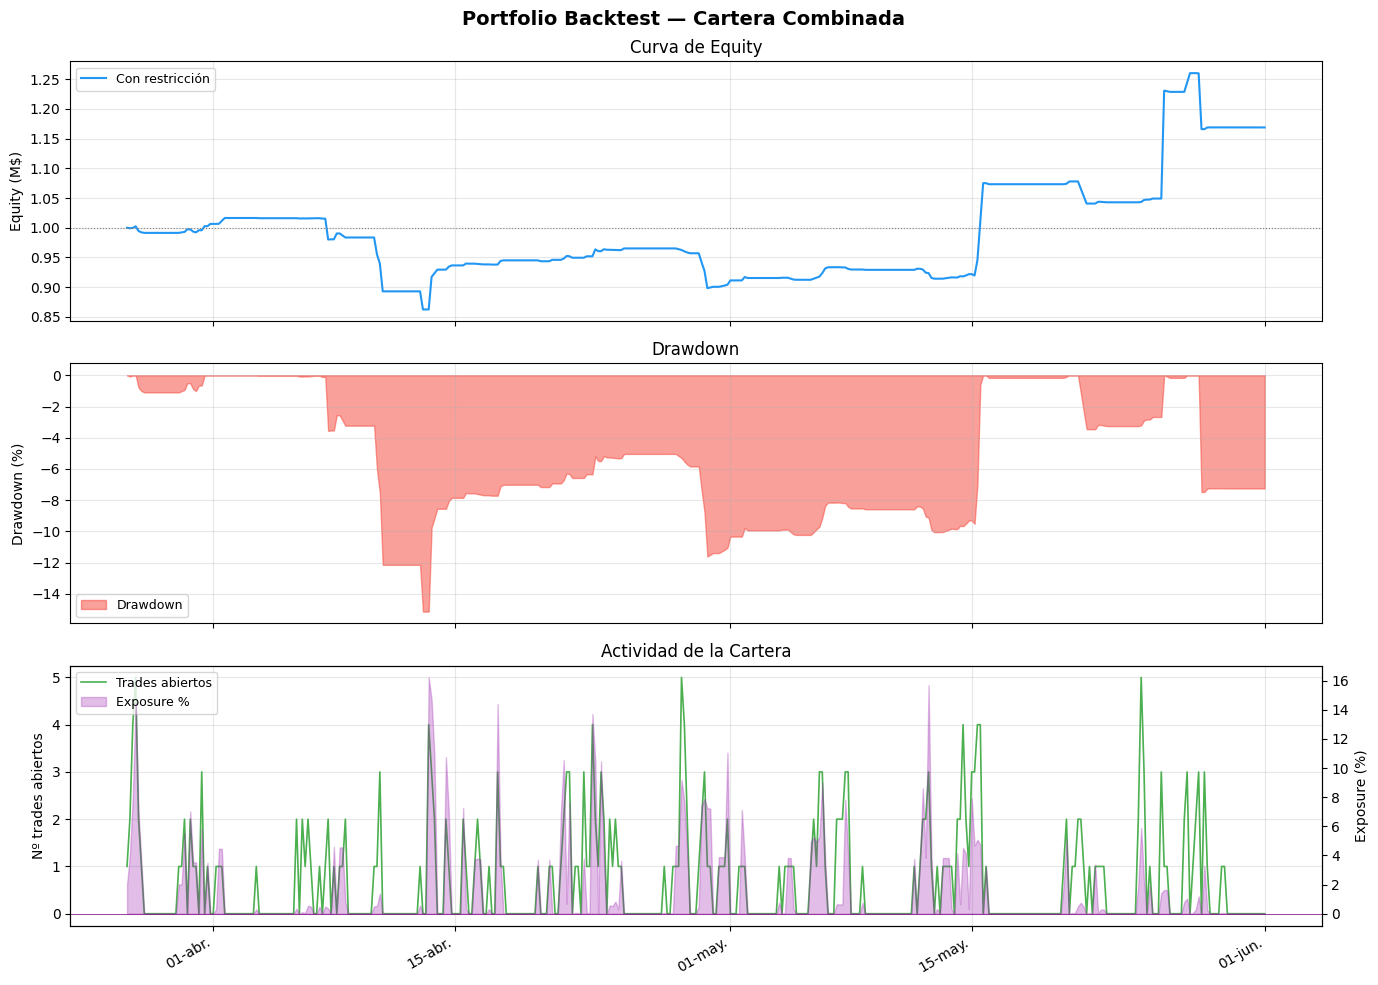

In [87]:
# ── Carga de datos (ajusta las rutas) ────────────────────────────────────
# trades_df  = pd.read_csv("trades.csv")      # o desde tu variable en memoria
# timeline_df = pd.read_csv("timeline.csv")
# ── Ejemplo con datos sintéticos mínimos ─────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

dates = pd.date_range(start=start, end=end, freq=f"{MINUTES} min", tz="UTC")
timeline_example = pd.DataFrame({"datetime": dates})

equity_df, summary = run_backtest(
    trades_df=filtered,
    timeline_df=timeline_example,
    initial_capital=1_000_000,
    max_exposure_pct=0.25,
    verbose=True,
)
print_metrics(summary)
comparison = compare_vs_unlimited(
    trades_df=filtered,
    timeline_df=timeline_example,
    initial_capital=1_000_000,
    max_exposure_pct=0.25,
)
print("\nCOMPARATIVA:")
print(comparison.to_string())
plot_equity_curve(
    summary_constrained=summary,
    initial_capital=1_000_000,
)